In [1]:
%load_ext autoreload
%autoreload 2
import mph
import numpy as np

from mphsweepkit.utils import *

In [2]:
client = mph.start()

model = client.load('core_cross_section_solved.mph')

In [3]:
study_name = 'Study on Cross-Sections'

# The cascaded sweeps are all accessed on the same level.
geometric_sweep = model / "studies" / study_name / "Geometry Sweep"
material_sweep = model / "studies" / study_name / "Material Sweep"
excitation_sweep = model / "studies" / study_name / "Excitation Sweep"
frequency_sweep = model / "studies" / study_name / "Frequency Sweep"

In [4]:
# Build the cascaded sweep table in the same order COMSOL uses internally.
geometry_data = get_sweep_data(geometric_sweep.properties())
material_data = get_material_data(material_sweep.properties())
excitation_data = get_sweep_data(excitation_sweep.properties())
frequency_data = get_frequency_data(frequency_sweep.properties())
all_combinations = get_cascaded_dataset(geometry_data, material_data, excitation_data, frequency_data)

# Pick one parameter combination to plot.
selected_parameters = {
    "hor_slit": 0.0,
    "vert_slit": 0.0,
    "w": 20.0,
    "l_r": 0.0,
    "a_e": 10.0,
    "b_mean": 50.0,
    "freq": 900.0,
}

# Filter the table down to the row that matches the chosen parameter values.
matches = all_combinations.copy()
for name, value in selected_parameters.items():
    matches = matches[np.isclose(matches[name].astype(float), float(value))]

if matches.empty:
    raise ValueError(f"No solution matches {selected_parameters}")

# Convert the selected row into COMSOL's outer and inner solution indices.
# The outer solution is the parametric sweep point for geometry/excitation.
# The inner solution is the frequency point inside that outer parameter case.
selected_row = matches.iloc[0]
outer_columns = [name for name in all_combinations.columns if name != "freq"]
outer_combinations = all_combinations[outer_columns].drop_duplicates().reset_index(drop=True)
outer_match = outer_combinations.copy()
for name in outer_columns:
    outer_match = outer_match[np.isclose(outer_match[name].astype(float), float(selected_row[name]))]

frequency_values = np.asarray(frequency_data["frequencies"], dtype=float)
frequency_match = np.where(np.isclose(frequency_values, float(selected_row["freq"])))

selected_outer_solnum = int(outer_match.index[0]) + 1
selected_inner_solnum = int(frequency_match[0][0]) + 1

print("Selected combination:")
print(selected_row.to_dict())
print(f"Using outer solution index (geometry - excitation) {selected_outer_solnum}")
print(f"Using inner solution index (frequency) {selected_inner_solnum}")

# The plot group owns the active dataset and solution indices in this COMSOL setup.
plot_group = model / "plots" / "Magnetic Flux Density (mf)"
parametric_dataset_tag = next(
    d.tag() for d in model / "datasets" if "Parametric Solutions" in d.name()
)

plot_group.property("data", parametric_dataset_tag)
plot_group.property("solutionparams", "manual")
plot_group.property("outersolnum", selected_outer_solnum)
plot_group.property("solnum", selected_inner_solnum)

plot_B = plot_group / "B"
plot_B.run()

Selected combination:
{'hor_slit': 0.0, 'vert_slit': 0.0, 'w': 20.0, 'l_r': 0.0, 'a_e': 10.0, 'matsw.comp1.core': 2.0, 'b_mean': 50.0, 'freq': 900.0}
Using outer solution index (geometry - excitation) 6
Using inner solution index (frequency) 9


In [5]:
# List available exports
exports = model.exports()
print(f"Available exports: {exports}")


export_B = model / "exports" / "Plot B"

# set the filename where the plot should be exported to
export_B.property('filename', 'B_plot.txt')
# export_B.properties()

Available exports: ['Plot B']


In [6]:
# Export 'Plot B' to a text file
model.export('Plot B', 'B_plot.txt')

In [7]:
# Read the exported text file into a pandas DataFrame and display the first few rows
read_df = read_comsol_txt_to_df("B_plot.txt")
read_df.head()

,x,y,Magnetic flux density norm
0,-0.010532,-0.005751,0.000017
1,-0.010916,-0.004985,0.000017
2,-0.010794,-0.005242,0.000017
3,-0.010667,-0.005498,0.000017
4,-0.010662,-0.004973,0.000017


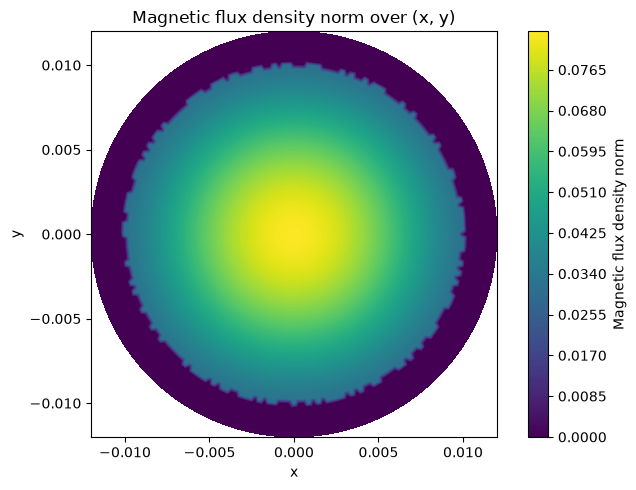

In [8]:
# Plot the data using tricontourf
plot_comsol_df(read_df, 
               x_col="x", 
               y_col="y", 
               value_col="Magnetic flux density norm", 
               kind="tricontourf",
               levels=200)